# NZZ Articles — Data Exploration

## 1. Setup & Data Loading

In [24]:
import sys
sys.path.insert(0, '../src')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from preprocess import load_dataset, preprocess

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_colwidth', 80)

In [25]:
# Load raw data (all fields)
df_raw = load_dataset()

# Cleaned dataset (filtered by MIN_TEXT_LENGTH, HTML removed)
df = preprocess(df_raw)

print(f'Raw data:       {len(df_raw):>7,} articles')
print(f'After cleaning: {len(df):>7,} articles  ({len(df_raw)-len(df):,} filtered)')
print(f'Time range:     {df["published_date"].min()}  →  {df["published_date"].max()}')

Raw data:        66,452 articles
After cleaning:  66,072 articles  (380 filtered)
Time range:     2023-01-01  →  2025-12-31


## 2. Overview & Basic Statistics

In [26]:
df.head(3)

,article_id,title,lead,body,category,subcategory,author,published_date,zeitung
0,311120768,EZB-Präsidentin Lagarde hilft jetzt nur noch ein Sieg über die Inflation,Die Französin hat zu lange auf ihren starrsinnigen Chefökonomen gehört und s...,Die Französin hat zu lange auf ihren starrsinnigen Chefökonomen gehört und s...,Meinung und Debatte,Meinung und Debatte,"Michael Rasch, Frankfurt",2023-01-31,nzz.ch
1,311064739,Norman Mailer war ein grandioser Schriftsteller – mit einem Gewaltproblem. E...,Vor hundert Jahren wurde der streitbare Autor in New Jersey geboren. Er hat ...,Vor hundert Jahren wurde der streitbare Autor in New Jersey geboren. Er hat ...,Feuilleton,Feuilleton,Steven Thomsen,2023-01-31,nzz.ch
2,311117046,Das beste Neujahrsgeschenk wäre eine gute Nachricht von der Front. Und da is...,Sergei Gerasimow harrt in Charkiw aus. In seinem Kriegstagebuch berichtet de...,Sergei Gerasimow harrt in Charkiw aus. In seinem Kriegstagebuch berichtet de...,Feuilleton,Feuilleton,Sergei Gerasimow,2023-01-31,nzz.ch


In [27]:
# Spaltentypen und Nicht-Null-Anteile
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66072 entries, 0 to 66071
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   article_id      66072 non-null  object
 1   title           66072 non-null  object
 2   lead            66072 non-null  object
 3   body            66072 non-null  object
 4   category        66072 non-null  object
 5   subcategory     66072 non-null  object
 6   author          66072 non-null  object
 7   published_date  66072 non-null  object
 8   zeitung         66072 non-null  object
dtypes: object(9)
memory usage: 4.5+ MB


In [28]:
# Basic statistics for text columns
df['body_len_chars']  = df['body'].str.len()
df['body_len_words']  = df['body'].str.split().str.len()
df['title_len_words'] = df['title'].str.split().str.len()

df[['body_len_chars', 'body_len_words', 'title_len_words']].describe().round(1)

,body_len_chars,body_len_words,title_len_words
count,66072.0,66072.0,66072.0
mean,6771.8,968.3,12.8
std,4198.3,616.6,5.4
min,101.0,12.0,1.0
25%,4421.0,621.0,9.0
50%,6123.0,870.0,13.0
75%,8249.0,1172.0,17.0
max,158273.0,22627.0,37.0


## 3. Temporal Distribution

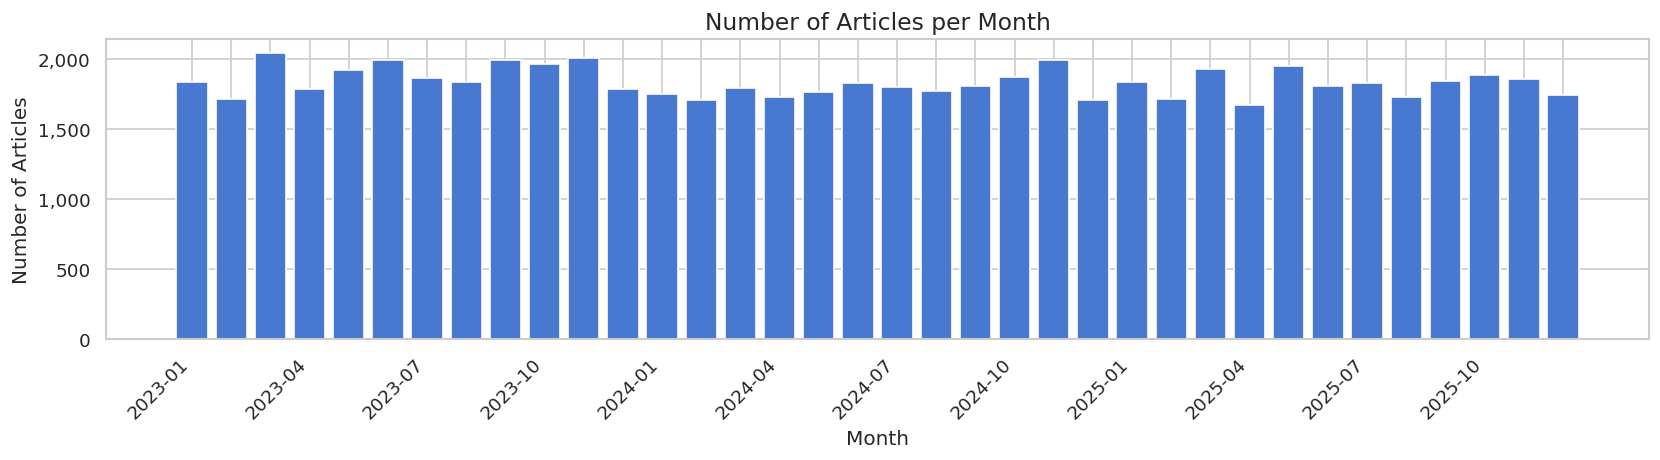

In [29]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['year_month'] = df['published_date'].dt.to_period('M')
df['year']       = df['published_date'].dt.year
df['month']      = df['published_date'].dt.month

monthly = df.groupby('year_month').size().reset_index(name='count')
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['year_month_str'], monthly['count'], color=sns.color_palette('muted')[0], width=0.8)
ax.set_title('Number of Articles per Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Articles')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Show only every 3rd label
labels = monthly['year_month_str'].tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l if i % 3 == 0 else '' for i, l in enumerate(labels)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

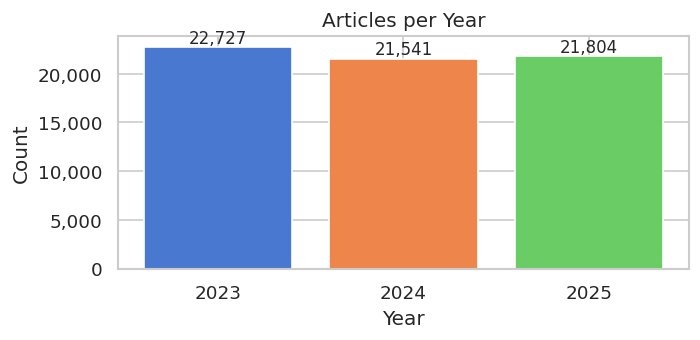

In [30]:
# Yearly comparison
yearly = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(yearly['year'].astype(str), yearly['count'],
              color=sns.color_palette('muted')[:len(yearly)])
for bar, val in zip(bars, yearly['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Articles per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

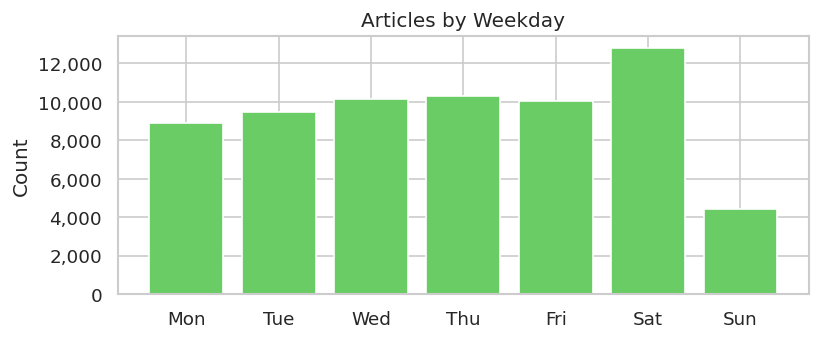

In [31]:
# Weekday distribution
df['weekday'] = df['published_date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_counts = df['weekday'].value_counts().reindex(day_order).fillna(0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(day_labels, weekday_counts.values, color=sns.color_palette('muted')[2])
ax.set_title('Articles by Weekday')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 4. Sections & Categories

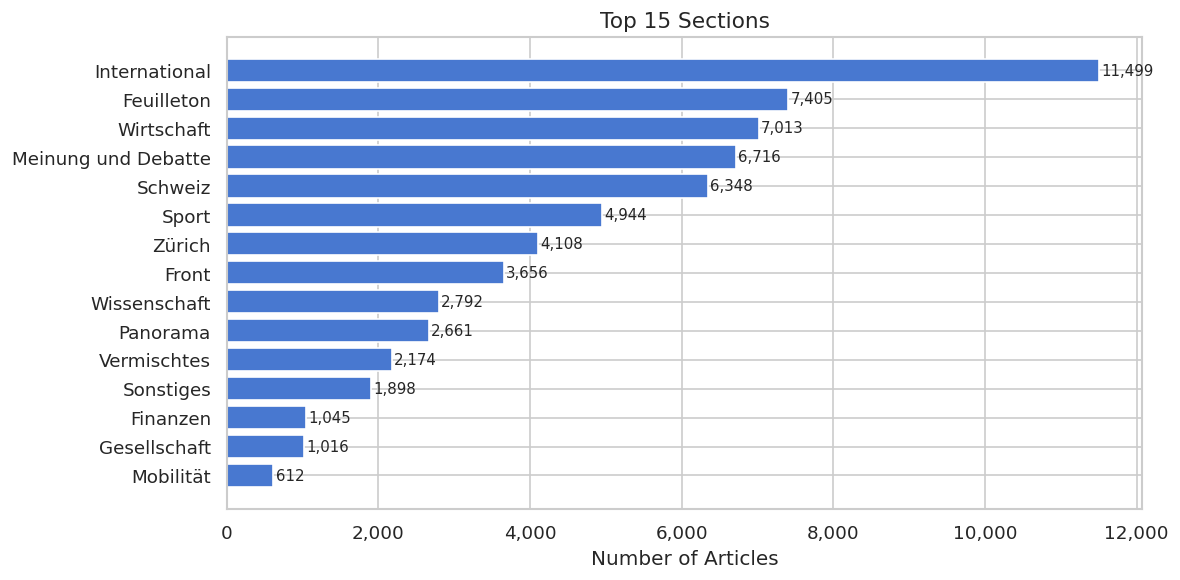

In [32]:
# Top sections
top_ressorts = df['category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_ressorts.index[::-1], top_ressorts.values[::-1],
               color=sns.color_palette('muted')[0])
for bar, val in zip(bars, top_ressorts.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Sections', fontsize=13)
ax.set_xlabel('Number of Articles')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

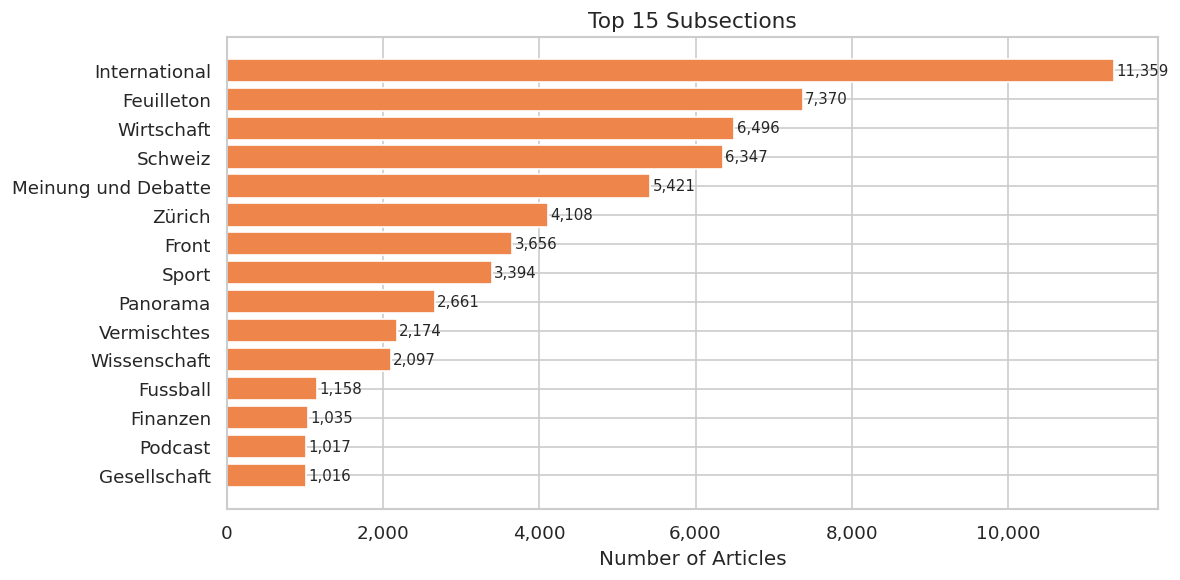

In [33]:
# Top subsections
top_sub = df['subcategory'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_sub.index[::-1], top_sub.values[::-1],
               color=sns.color_palette('muted')[1])
for bar, val in zip(bars, top_sub.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 Subsections', fontsize=13)
ax.set_xlabel('Number of Articles')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

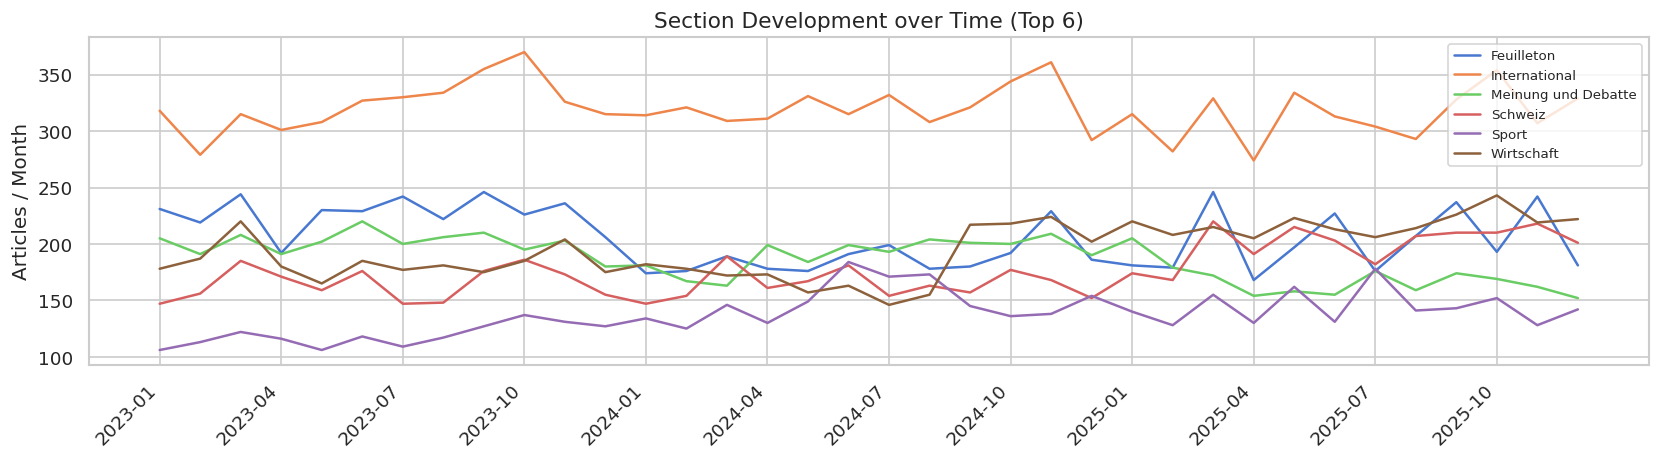

In [34]:
# Section development over time (Top 6)
top6 = df['category'].value_counts().head(6).index.tolist()
pivot = (df[df['category'].isin(top6)]
           .groupby(['year_month', 'category'])
           .size()
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 4))
for col in pivot.columns:
    ax.plot(pivot.index.astype(str), pivot[col], label=col, linewidth=1.5)
# Show only every 3rd label
ticks = list(range(len(pivot)))
ax.set_xticks([t for t in ticks if t % 3 == 0])
ax.set_xticklabels([str(pivot.index[t]) for t in ticks if t % 3 == 0], rotation=45, ha='right')
ax.set_title('Section Development over Time (Top 6)', fontsize=13)
ax.set_ylabel('Articles / Month')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Authors

In [35]:
# Clean author name (name only, without location)
df['author_clean'] = df['author'].str.split(',').str[0].str.strip()

total_articles  = len(df)
n_authors       = df['author_clean'].nunique()
no_author_pct   = (df['author_clean'].isin(['', 'nan']) | df['author_clean'].isna()).mean() * 100

print(f'Unique authors:          {n_authors:,}')
print(f'Articles without author: {no_author_pct:.1f}%')

Unique authors:          4,269
Articles without author: 11.1%


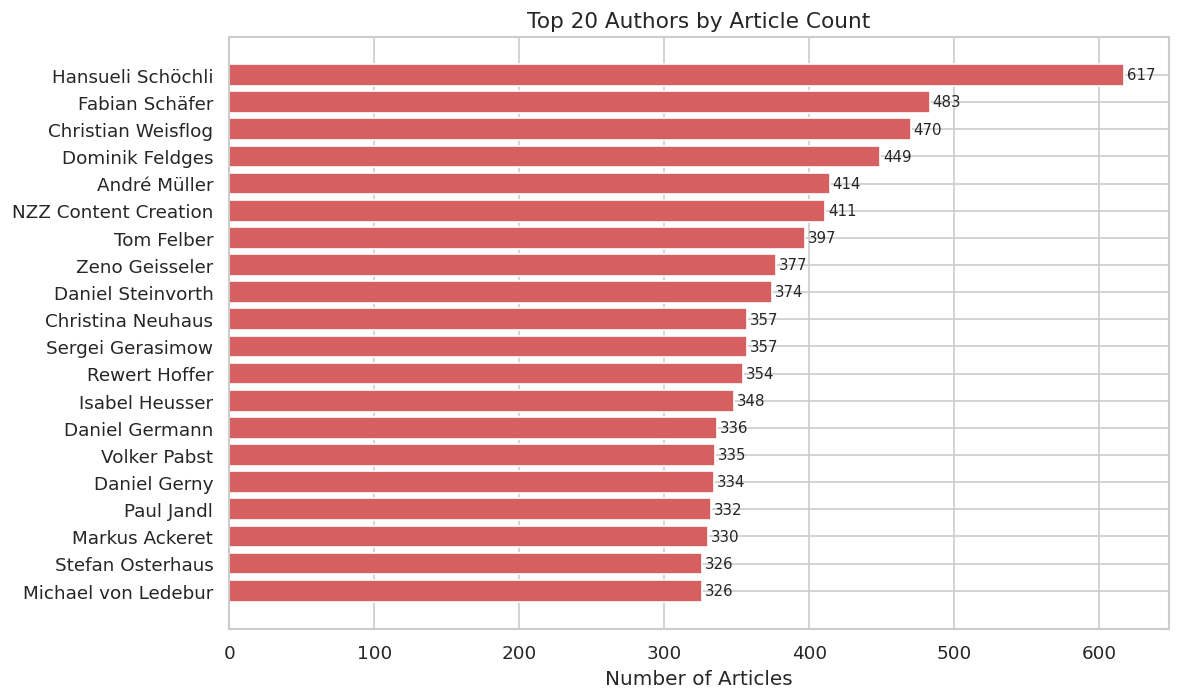

In [36]:
# Top 20 authors by article count
top_authors = (df[df['author_clean'].notna() & (df['author_clean'] != '')]
               ['author_clean'].value_counts().head(20))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=sns.color_palette('muted')[3])
for bar, val in zip(bars, top_authors.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_title('Top 20 Authors by Article Count', fontsize=13)
ax.set_xlabel('Number of Articles')
plt.tight_layout()
plt.show()

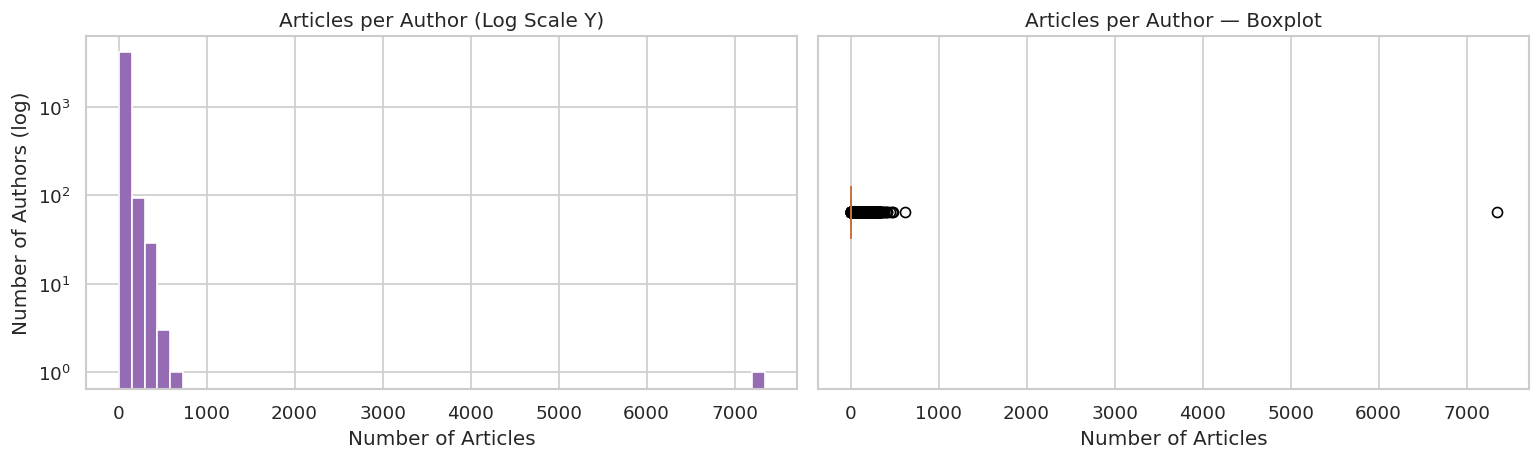

count    4269.0
mean       15.5
std       121.4
min         1.0
25%         1.0
50%         1.0
75%         4.0
max      7339.0
Name: count, dtype: float64

Author with fewest articles: Nicolas Staub (1)
Author with most articles:    (7339)


In [37]:
# Distribution: How many articles does a typical author write?
author_counts = df['author_clean'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (log-scaled y)
axes[0].hist(author_counts.values, bins=50, log=True,
             color=sns.color_palette('muted')[4], edgecolor='white')
axes[0].set_title('Articles per Author (Log Scale Y)')
axes[0].set_xlabel('Number of Articles')
axes[0].set_ylabel('Number of Authors (log)')

# Boxplot
axes[1].boxplot(author_counts.values, vert=False, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[4]))
axes[1].set_title('Articles per Author — Boxplot')
axes[1].set_xlabel('Number of Articles')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(author_counts.describe().round(1))
print(f'\nAuthor with fewest articles: {author_counts.idxmin()} ({author_counts.min()})')
print(f'Author with most articles:   {author_counts.idxmax()} ({author_counts.max()})')

## 6. Text Lengths

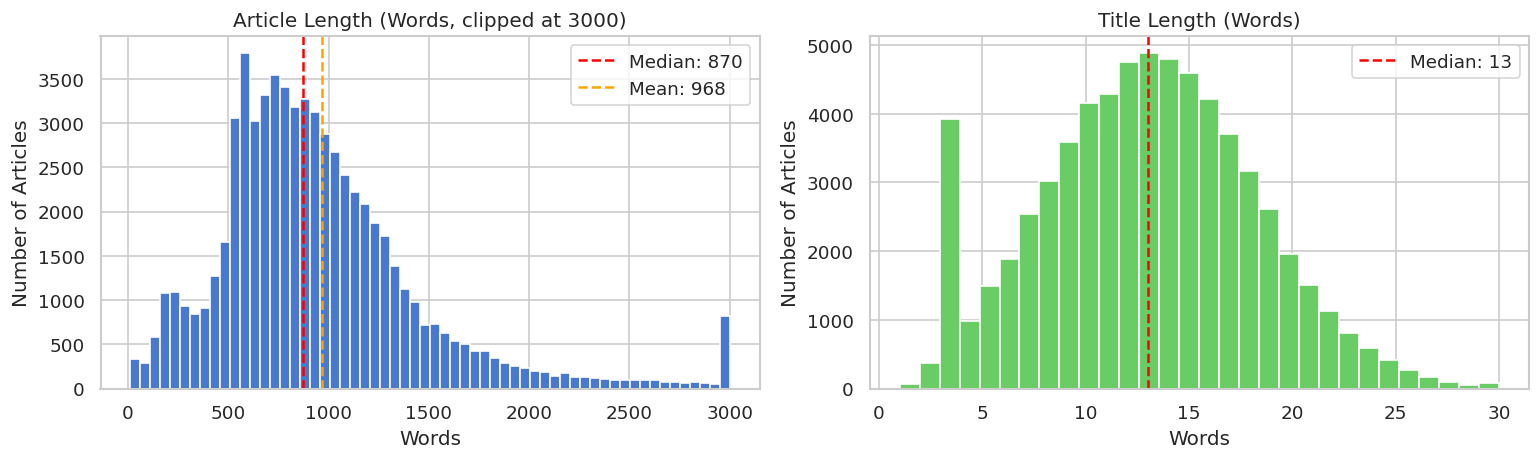

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Body length in words
axes[0].hist(df['body_len_words'].clip(upper=3000), bins=60,
             color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].axvline(df['body_len_words'].median(), color='red', linestyle='--',
                label=f'Median: {df["body_len_words"].median():.0f}')
axes[0].axvline(df['body_len_words'].mean(), color='orange', linestyle='--',
                label=f'Mean: {df["body_len_words"].mean():.0f}')
axes[0].set_title('Article Length (Words, clipped at 3000)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Number of Articles')
axes[0].legend()

# Title length in words
axes[1].hist(df['title_len_words'].clip(upper=30), bins=30,
             color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].axvline(df['title_len_words'].median(), color='red', linestyle='--',
                label=f'Median: {df["title_len_words"].median():.0f}')
axes[1].set_title('Title Length (Words)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Number of Articles')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_22664/1437021934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='category', y='body_len_words', order=order,
/tmp/ipykernel_22664/1437021934.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


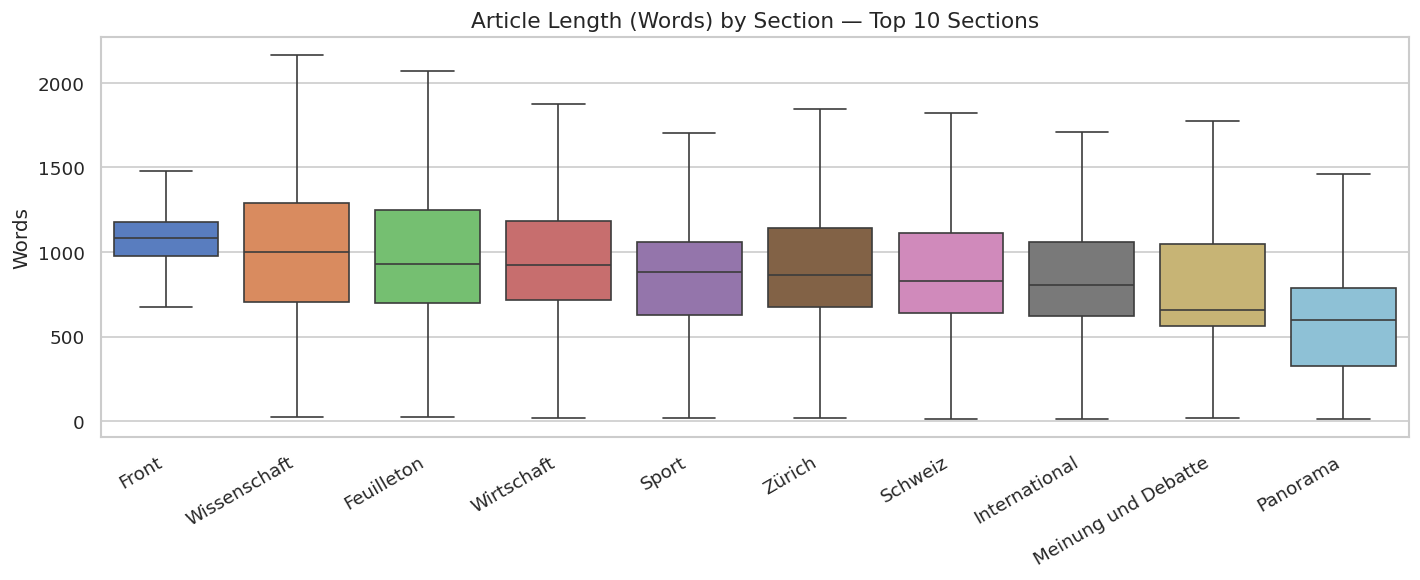

In [39]:
# Text length by section (Top 10)
top10_cat = df['category'].value_counts().head(10).index
df_top10  = df[df['category'].isin(top10_cat)]

order = (df_top10.groupby('category')['body_len_words']
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_top10, x='category', y='body_len_words', order=order,
            palette='muted', showfliers=False, ax=ax)
ax.set_title('Article Length (Words) by Section — Top 10 Sections', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Words')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

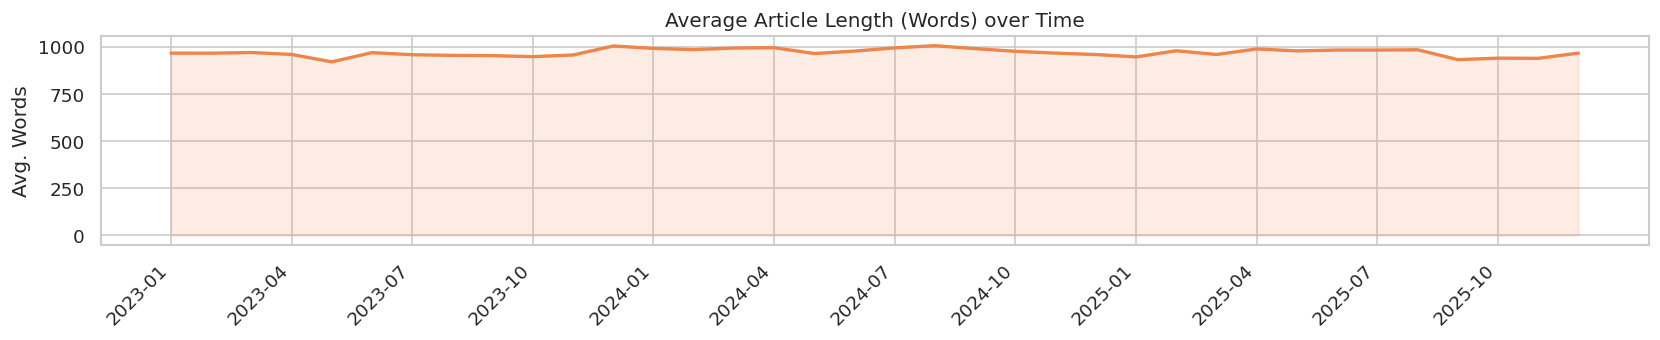

In [40]:
# Average text length over time
monthly_len = df.groupby('year_month')['body_len_words'].mean()

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(monthly_len.index.astype(str), monthly_len.values,
        color=sns.color_palette('muted')[1], linewidth=2)
ax.fill_between(range(len(monthly_len)), monthly_len.values,
                alpha=0.15, color=sns.color_palette('muted')[1])
ticks = list(range(len(monthly_len)))
ax.set_xticks([t for t in ticks if t % 3 == 0])
ax.set_xticklabels([str(monthly_len.index[t]) for t in ticks if t % 3 == 0],
                   rotation=45, ha='right')
ax.set_title('Average Article Length (Words) over Time')
ax.set_ylabel('Avg. Words')
plt.tight_layout()
plt.show()

## 7. Data Quality & Missing Values

                missing_count  missing_pct
title                       0         0.00
lead                      795         1.20
body                        0         0.00
category                    0         0.00
subcategory                 0         0.00
author                   7339        11.11
published_date              0         0.00


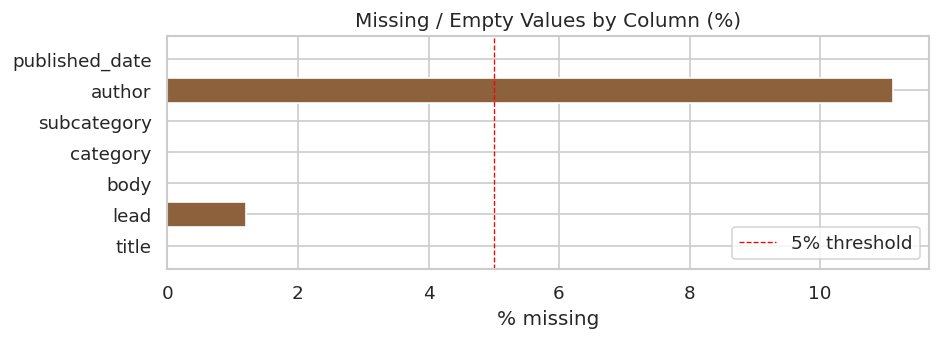

In [41]:
# Missing / empty values per column
cols_of_interest = ['title', 'lead', 'body', 'category', 'subcategory', 'author', 'published_date']
missing = pd.DataFrame({
    'missing_count':   df[cols_of_interest].isnull().sum() + (df[cols_of_interest] == '').sum(),
    'missing_pct':    (df[cols_of_interest].isnull().sum() + (df[cols_of_interest] == '').sum()) / len(df) * 100
}).round(2)

print(missing.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(missing.index, missing['missing_pct'],
        color=sns.color_palette('muted')[5])
ax.set_title('Missing / Empty Values by Column (%)')
ax.set_xlabel('% missing')
ax.axvline(5, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# Articles without lead (teaser)
no_lead = df['lead'].isna() | (df['lead'] == '')
print(f'Articles without lead:  {no_lead.sum():,}  ({no_lead.mean()*100:.1f}%)')

# Duplicates (same article_id)
dupes = df.duplicated(subset='article_id').sum()
print(f'Duplicate article_id:   {dupes:,}')

# Very short articles (< 50 words)
very_short = (df['body_len_words'] < 50).sum()
print(f'Articles < 50 words:    {very_short:,}  ({very_short/len(df)*100:.1f}%)')

# Very long articles (> 5000 words)
very_long = (df['body_len_words'] > 5000).sum()
print(f'Articles > 5000 words:  {very_long:,}  ({very_long/len(df)*100:.1f}%)')

Articles without lead:  795  (1.2%)
Duplicate article_id:   1
Articles < 50 words:    300  (0.5%)
Articles > 5000 words:  143  (0.2%)


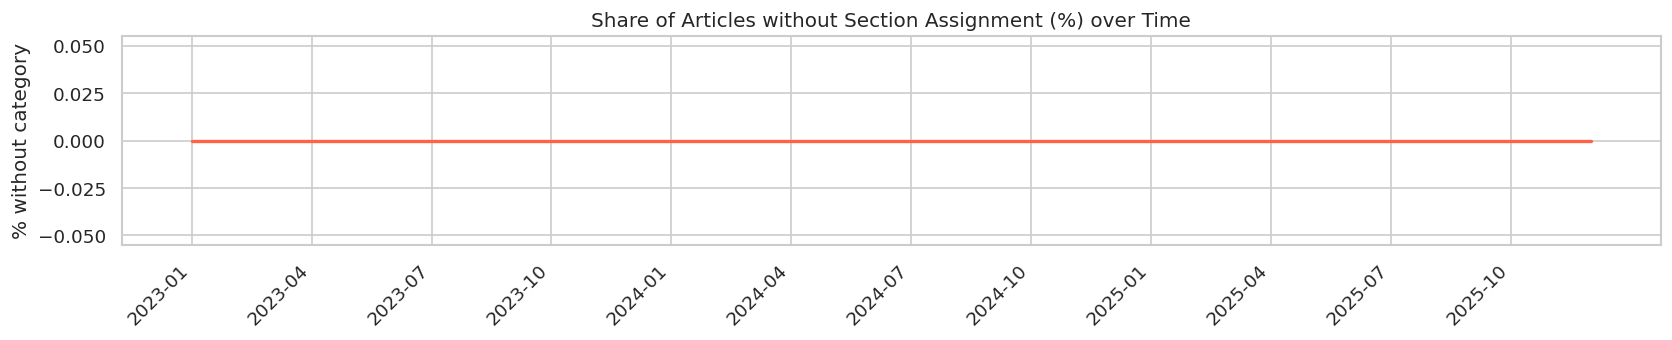

In [43]:
# Articles with missing category over time
df['no_category'] = df['category'] == ''
missing_cat_monthly = df.groupby('year_month')['no_category'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(missing_cat_monthly.index.astype(str), missing_cat_monthly.values,
        color='tomato', linewidth=2)
ticks = list(range(len(missing_cat_monthly)))
ax.set_xticks([t for t in ticks if t % 3 == 0])
ax.set_xticklabels([str(missing_cat_monthly.index[t]) for t in ticks if t % 3 == 0],
                   rotation=45, ha='right')
ax.set_title('Share of Articles without Section Assignment (%) over Time')
ax.set_ylabel('% without category')
plt.tight_layout()
plt.show()